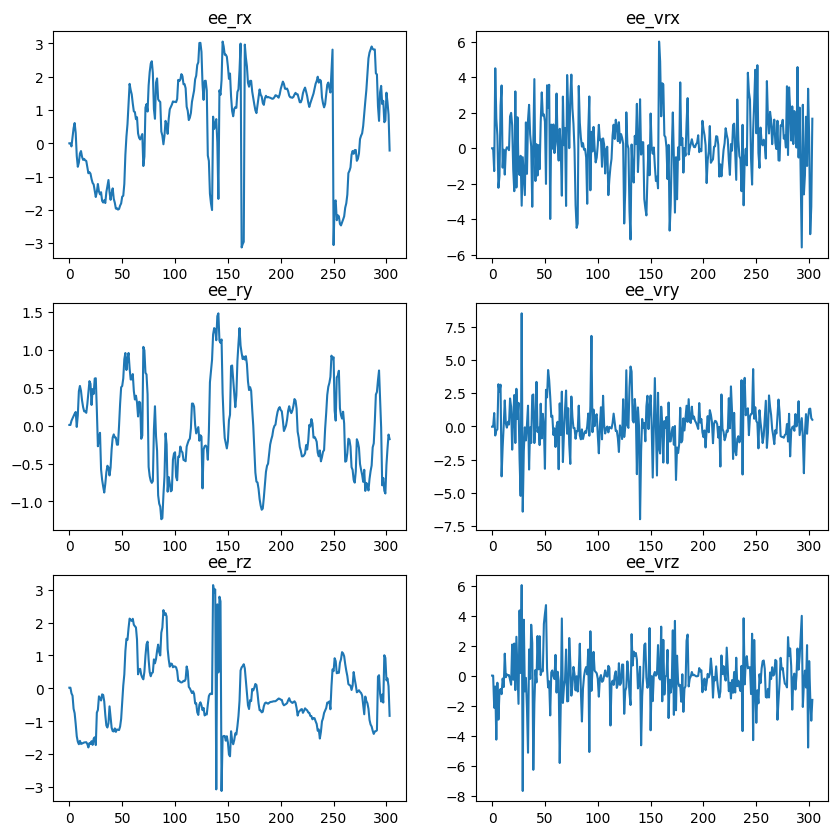

In [22]:
"""Analyse data collected on real robot"""

import os
import pickle
import numpy as np
import jax.numpy as jnp

file_name = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241028-101042_data_collection/brax_transitions.pickle"

state_label_dict = {
    0: "x",
    1: "y",
    2: "sin_theta",
    3: "cos_theta",
    4: "vx",
    5: "vy",
    6: "vtheta",
    7: "eex",
    8: "eey",
    9: "eez",
    10: "eevx",
    11: "eevy",
    12: "eevz",
    13: "sin_eerx",
    14: "cos_eerx",
    15: "sin_eery",
    16: "cos_eery",
    17: "sin_eerz",
    18: "cos_eerz",
    19: "eervx",
    20: "eervy",
    21: "eervz"
}


def load_data(file_name):
    with open(file_name, "rb") as f:
        data = pickle.load(f)
    return data

data = load_data(file_name)

observations = [x.observation for x in data]
# plot ee_rx, ee_ry, ee_rz and ee_vrx, ee_vry, ee_vrz (convert from sin/cos to angle if necessary)
import matplotlib.pyplot as plt
import seaborn as sns

observations = np.array(observations)

ee_rx = np.arctan2(observations[:, 13], observations[:, 14])
ee_ry = np.arctan2(observations[:, 15], observations[:, 16])
ee_rz = np.arctan2(observations[:, 17], observations[:, 18])

ee_vrx = observations[:, 19]
ee_vry = observations[:, 20]
ee_vrz = observations[:, 21]

fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs[0, 0].plot(ee_rx)
axs[0, 0].set_title("ee_rx")
axs[1, 0].plot(ee_ry)
axs[1, 0].set_title("ee_ry")
axs[2, 0].plot(ee_rz)
axs[2, 0].set_title("ee_rz")

axs[0, 1].plot(ee_vrx)
axs[0, 1].set_title("ee_vrx")
axs[1, 1].plot(ee_vry)
axs[1, 1].set_title("ee_vry")
axs[2, 1].plot(ee_vrz)
axs[2, 1].set_title("ee_vrz")

plt.show()

